# Introduction to Pytorch

In [2]:
# Test if widgets are working

import ipywidgets as widgets
from IPython.display import display

slider = widgets.IntSlider(min=0, max=10, step=1, description='Value:')
display(slider)

IntSlider(value=0, description='Value:', max=10)

## Import dependencies

If using Google Colab, all the packages listed below should be pre-installed.

In [2]:
# --- Standard libraries ---
import os
import math
import numpy as np
import time
import torch

# --- Imports for plotting ---
import matplotlib.pyplot as plt
%matplotlib inline
from matplotlib_inline.backend_inline import set_matplotlib_formats
# For export
set_matplotlib_formats('svg', 'pdf')
from matplotlib.colors import to_rgba

import seaborn as sns
sns.set()

# --- Progress bar ---
from tqdm.notebook import tqdm

## The Basics of PyTorch

The package is called `torch`.

In [3]:
import torch
print("Using torch:", torch.__version__)

Using torch: 2.6.0


PyTorch provides functions that are stochastic like generating random numbers.


It's a **good practice** to make your code **reproducible** by setting the **exact same random numbers**.

In [4]:
torch.manual_seed(11)

### Tensors

* **Tensors** are similar to **numpy arrays**, and many operations from numpy can be used on tensors.
* **Tensor** is a **generalization** of concepts from **matrices and vectors**.
  * a vector is a 1-D tensor
  * a matrix is a 2-D tensor

#### Initialization

Different ways to create tensors.
* **`torch.Tensor()`(size)**: create a tensor by the **given shape**.
* **`torch.zeros()`**: create a tensor by the given **shape filled with `0`**.
* **`torch.ones()`**: create a tensor by the given **shape filled with `1`**.
* **`torch.rand()`**: create a tensor by the given **shape filled with random values uniformly sampled between `0` and `1`**.
* **`torch.randn()`**: create a tensor by the given **shape filled with random values sampled from a normal distribution with mean `0` and variance `1`**.
* **`torch.arange(start, end)`**: create a tensor containing the **values from `start` to `end`(not included)**.
* **`torch.Tensor()`(input list)**: create a tensor with **exact given values**.

`torch.Tensor()` **allocates memory** for the tensor and **reuses** any values that have already been in the memory.

In [5]:
tensor_by_shape = torch.Tensor(1, 2, 3)
tensor_with_zeros = torch.zeros(1, 2, 3)
tensor_with_ones = torch.ones(1, 2, 3)
tensor_with_rand = torch.rand(1, 2, 3)
tensor_with_randn = torch.randn(1, 2, 3)
tensor_with_arange = torch.arange(0, 9)
tensor_with_give_values = torch.Tensor([[1, 2], [3, 4]])


print(tensor_by_shape)
print("-------------------")
print(tensor_with_zeros)
print("-------------------")
print(tensor_with_ones)
print("-------------------")
print(tensor_with_rand)
print("-------------------")
print(tensor_with_randn)
print("-------------------")
print(tensor_with_arange)
print("-------------------")
print(tensor_with_give_values)

tensor([[[0., 0., 0.],
         [0., 0., 0.]]])
-------------------
tensor([[[0., 0., 0.],
         [0., 0., 0.]]])
-------------------
tensor([[[1., 1., 1.],
         [1., 1., 1.]]])
-------------------
tensor([[[0.1490, 0.4866, 0.9857],
         [0.1684, 0.5839, 0.6936]]])
-------------------
tensor([[[-0.6700, -1.1277,  0.3497],
         [ 0.5125,  1.2068,  1.4048]]])
-------------------
tensor([0, 1, 2, 3, 4, 5, 6, 7, 8])
-------------------
tensor([[1., 2.],
        [3., 4.]])


Obtain the **shape** of a tensor by **`.shape`** attribute or the **`.size()`** method.

In [6]:
x = torch.Tensor(1, 2, 3)
print(f"shape: {x.shape}")
print(f"size: {x.size()}")
print("-------------------")

dim1, dim2, dim3 = x.size()
print(f"dimension1: {dim1}")
print(f"dimension2: {dim2}")
print(f"dimension3: {dim3}")

shape: torch.Size([1, 2, 3])
size: torch.Size([1, 2, 3])
-------------------
dimension1: 1
dimension2: 2
dimension3: 3


### Tensor to Numpy and vice visa

* **Tensor to numpy**: **`.numpy()`** method
  * In order to convert a tensor to a numpy array, you need the **tensor on the CPU**, so **`np_arr = tensor.cpu().numpy()`**, not the GPU.
* **Numpy to tensor**: **`torch.from_numpy()`**.

In [7]:
# Tensor to numpy
tensor = torch.Tensor(1, 2, 3)
print(f"type: {type(tensor)}")
tensor_to_numpy = tensor.numpy()
print(f"type: {type(tensor_to_numpy)}")
print("-------------------")

# Numpy to tensor
np_array = np.array([[1, 2], [3, 4]])
print(f"type: {type(np_array)}")
numpy_to_tensor = torch.from_numpy(np_array)
print(f"type: {type(numpy_to_tensor)}")

type: <class 'torch.Tensor'>
type: <class 'numpy.ndarray'>
-------------------
type: <class 'numpy.ndarray'>
type: <class 'torch.Tensor'>


### Opeartions

* **Add** two tensors
  * creating a **new** tensor: **`+`**.
  * **In-place add**: by **`<tensor>.add_(<ano_tensor>)`**.
* Changing the **shape** of a tensor with the same values: **`.view()`**.

**In-place ops** are usually marked with **underscore postfix**, eg, **`add_`**.

In [8]:
# Add by create a new tensor
x1 = torch.rand(1, 2)
x2 = torch.rand(1, 2)
y = x1 + x2

print("X1", x1)
print("X2", x2)
print("Y", y)
print("X1 + X2 == Y", x1 + x2 == y)
print("-------------------")

# In-place add
print("X1 + X2", x2.add_(x1))
print("X2", x2)
print("-------------------")

# Changing shape
x_original = torch.arange(0, 9)
x_reorganized = x_original.view(3, 3)
print("x_original(1 * 9)", x_original)
print("x_reorganized(3 * 3)", x_reorganized)

X1 tensor([[0.8035, 0.7653]])
X2 tensor([[0.8709, 0.7231]])
Y tensor([[1.6744, 1.4884]])
X1 + X2 == Y tensor([[True, True]])
-------------------
X1 + X2 tensor([[1.6744, 1.4884]])
X2 tensor([[1.6744, 1.4884]])
-------------------
x_original(1 * 9) tensor([0, 1, 2, 3, 4, 5, 6, 7, 8])
x_reorganized(3 * 3) tensor([[0, 1, 2],
        [3, 4, 5],
        [6, 7, 8]])


**Matrix multiplications**

* **`torch.matmul`**: 
  * same to **`a @ b`**
  * support **broadcasting**
* **`torch.mm`**
  * doesn't support **broadcasting**
* **`torch.bmm`**
  * perform **batch matrix multiplication**
  * T(with shape: b * n * m) * R(with shape: b * m * p) = O(with shape: b * n * p)
* **`torch.einsum`**
  * support matrix multiplication and more(i.e. sums of products) using Einstein summation convention.
  
Usually, we use `torch.matmul` or `torch.bmm`.

In [9]:
x = torch.arange(6)
x = x.view(2, 3)
print("X", x)

W = torch.arange(9).view(3, 3)
print("W", W)

output = torch.matmul(x, W)
print("output", output)

X tensor([[0, 1, 2],
        [3, 4, 5]])
W tensor([[0, 1, 2],
        [3, 4, 5],
        [6, 7, 8]])
output tensor([[15, 18, 21],
        [42, 54, 66]])


### Indexing

**Selecting** a part of a tensor.

In [10]:
x = torch.arange(12).view(3, 4)
print("x:", x)

x: tensor([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]])


In [11]:
print("x:", x)

print("First column", x[:, 0])

print("Second column", x[:, 1])

print("First row", x[0, :])

print("Second row", x[1, :])

print("Element at first row and second column", x[0, 1])

print("First two rows and second column", x[:2, 1:2])

print("First row and the last column", x[0, -1])

x: tensor([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]])
First column tensor([0, 4, 8])
Second column tensor([1, 5, 9])
First row tensor([0, 1, 2, 3])
Second row tensor([4, 5, 6, 7])
Element at first row and second column tensor(1)
First two rows and second column tensor([[1],
        [5]])
First row and the last column tensor(3)


### Dynamic Computation Graph and Backpropagation



The only thing developers have to do is to **compute the output**, and PyTorch can **automatically get the gradients**.

* PyTorch can **automatically** get **gradients/derivatives of functions**.
* Weight matrices that could learn are called the **parameters** or the **weights**.
* If the neural network outputs **a single scalar value**, it's the **derivative**, but quite often we will have **multiple output variables**; in that case it's the **gradients**.


* As we manipulate the input, we are automatically creating a **computational graph**, which shows **how to arrive at the output from the input**. 
* PyTorch is a **define-by-run** framework, which means that we can just do manipulations, and PyTorch will keep track of that graph.


The first thing is to **specify which tensors require gradients**. 
* **By default**, the tensor created does **not** require gradients.
* Using **`requires_grad=True`** to specify that the tensor requires gradients.
* **Only float** tensors can have gradients.

In [12]:
x = torch.ones((3,))

print(x.requires_grad) # output "False"

False


In [13]:
x.requires_grad_(True)

print(x.requires_grad) # output "True"


True


<math xmlns="http://www.w3.org/1998/Math/MathML" display="block">
  <mi>y</mi>
  <mo>=</mo>
  <mfrac>
    <mn>1</mn>
    <mrow>
      <mi>&#x2113;</mi>
      <mo stretchy="false">(</mo>
      <mi>x</mi>
      <mo stretchy="false">)</mo>
    </mrow>
  </mfrac>
  <munder>
    <mo data-mjx-texclass="OP">&#x2211;</mo>
    <mi>i</mi>
  </munder>
  <mrow data-mjx-texclass="INNER">
    <mo data-mjx-texclass="OPEN">[</mo>
    <mo stretchy="false">(</mo>
    <msub>
      <mi>x</mi>
      <mi>i</mi>
    </msub>
    <mo>+</mo>
    <mn>2</mn>
    <msup>
      <mo stretchy="false">)</mo>
      <mn>2</mn>
    </msup>
    <mo>+</mo>
    <mn>3</mn>
    <mo data-mjx-texclass="CLOSE">]</mo>
  </mrow>
  <mo>,</mo>
</math>

Assume `x = [0, 1, 2]` as input

In [14]:
x = torch.arange(3, dtype=torch.float32, requires_grad=True)

print("X", x)

X tensor([0., 1., 2.], requires_grad=True)


The computation graph:

In [15]:
a = x + 2
b = a ** 2
c = b + 3
y = c.mean()
print("Y", y)

Y tensor(12.6667, grad_fn=<MeanBackward0>)


* Each node in the computation graph **automatically** defines a **function** for **calculating the gradients** with respect to its inputs, **`grad_fn`**
* Calling the function **`backward()`** on the last output to perform **backpropagation** to get the **gradients** of each tensors that has **`requires_grad=True`**

In [16]:
# perform backpropagation

y.backward()

<math xmlns="http://www.w3.org/1998/Math/MathML">
  <mi>&#x2202;</mi>
  <mi>y</mi>
  <mrow data-mjx-texclass="ORD">
    <mo>/</mo>
  </mrow>
  <mi>&#x2202;</mi>
  <mrow data-mjx-texclass="ORD">
    <mi data-mjx-variant="-tex-calligraphic" mathvariant="script">x</mi>
  </mrow>
</math>
:

In [17]:
# print the gradient of x
print(x.grad)

tensor([1.3333, 2.0000, 2.6667])


### GPU support 

* Pytorch supports GPU
* [What’s the Difference Between a CPU and a GPU? - NVIDIA Blog](https://blogs.nvidia.com/blog/whats-the-difference-between-a-cpu-and-a-gpu/)

Check if the GPU is available:

In [18]:
# --- Working on CUDA ---
# gpu_avail_win = torch.cuda.is_available()
# print(f"Is the GPU available? {gpu_avail_win}")


# --- Working on MPS ---
gpu_avail_mac = torch.backends.mps.is_available()
print(f"Is the GPU available on Mac? {gpu_avail_mac}")

Is the GPU available on Mac? True


* **By default**, the tensors created are on the **CPU**.
* We need to **move** the tensors to the GPU using **`.to()`** or **`.cuda()`**.
* It is a **good practice** to use **`device`** to point to the device to use so that we can run the same code on both CPU and GPU.

In [19]:
# --- Working on CUDA ---
# device_win = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
# print("Device", device_win)

# --- Working on MPS ---
device = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")
print("Device", device)

Device mps


Create a tensor and move it to the GPU

In [20]:
x = torch.zeros(2, 3)
x = x.to(device)

print("X", x)

X tensor([[0., 0., 0.],
        [0., 0., 0.]], device='mps:0')


* You can see the **`device='mps:0'`**(or `device='cuda:0'`) in the output, which means it's the 0-th GPU on the device. 
* Pytorch also supports **multi-GPU** systems.

In [21]:
# --- Performance benchmark ---
x_cpu = torch.randn(5000, 5000)

# CPU version
print("\n--- CPU Benchmark ---")
start_time_cpu = time.time()
_ = torch.matmul(x_cpu, x_cpu)
end_time_cpu = time.time()
print(f"CPU time: {(end_time_cpu - start_time_cpu):6.5f}s")

# GPU version
print("\n--- GPU Benchmark ---")
x_gpu = x_cpu.to(device)
# warm-up
_ = torch.matmul(x_gpu, x_gpu)
torch.mps.synchronize() # waits for MPS operations to finish

start_time_gpu = time.time()
_ = torch.matmul(x_gpu, x_gpu)
torch.mps.synchronize()
end_time_gpu = time.time()
print(f"GPU time: {(end_time_gpu - start_time_gpu):6.5f}s")


--- CPU Benchmark ---
CPU time: 0.26576s

--- GPU Benchmark ---
GPU time: 0.15517s


* When **generating random numbers**, the seed between CPU and GPU is **not synchronized**.
* To ensure **reproducibility**, we need to set the seed on the GPU separately.
* Note: Due to **different** GPU architectures, the random numbers generated by the same code may **not be the same**.
* Some operations on a GPU are implemented **stochastically** for efficiency. To ensure reproducibility, we need to make these operations **deterministic** by `torch.use_deterministic_algorithms(True)` or `torch.backends.cudnn.deterministic = True`

In [22]:
import torch
import os

# Set the seed for CPU
torch.manual_seed(0)

# For CUDA(NVIDIA GPU)
if torch.cuda.is_available():
  print("CUDA device found")
  torch.cuda.manual_seed(0)
  torch.cuda.manual_seed_all(0)

  torch.backends.cudnn.deterministic = True
  torch.backends.cudnn.benchmark = False
  print("CUDA manual seed set. cuDNN deterministic and benchmark flags set.")


# For MPS(Mac GPU)
if torch.backends.mps.is_available():
  print("MPS device found")
  torch.mps.manual_seed(0)

  torch.use_deterministic_algorithms(True)
  print("MPS manual seed set. Deterministic algorithms requested")

MPS device found
MPS manual seed set. Deterministic algorithms requested


## An example: Continuos XOR


A simple neuron(i.e., a linear classifier) **cannot** learn the XOR operation.

### The model

* **`torch.nn`** package defines the **building blocks** for neural networks.
* **torch.nn.functional** package defines the **functionalities** used in the neural networks.

In [23]:
import torch.nn as nn
import torch.nn.functional as F

In PyTorch, a neural network is built up out of **modules(`nn.Module`)**. Modules can contain other modules, and a neural network is considered to be a module itself as well.
* In **`__init__`**, we usually define the layers of the neural network using `nn.Parameter`.
* In **`forward`**, we define the forward pass(computation) of the neural network.
* The backward pass is done **automatically**.

In [24]:
class MyModule(nn.Module):
  def __init__(self):
    super().__init__()

  def forward(self, x):
    pass

A simple classifier:

In [25]:
class SimpleClassifier(nn.Module):
  def __init__(self, num_inputs, num_hidden, num_outputs):
    super().__init__()
    self.linear1 = nn.Linear(num_inputs, num_hidden)
    self.act_fn = nn.Tanh()
    self.linear2 = nn.Linear(num_hidden, num_outputs)
  
  def forward(self, x):
    x = self.linear1(x)
    x = self.act_fn(x)
    x = self.linear2(x)

    return x

Initialize the model.

In [26]:
model = SimpleClassifier(num_inputs=2, num_hidden=4, num_outputs=1)

print(model)

SimpleClassifier(
  (linear1): Linear(in_features=2, out_features=4, bias=True)
  (act_fn): Tanh()
  (linear2): Linear(in_features=4, out_features=1, bias=True)
)


Print the model and list all the submodules.

* The **parameters** of a module could be **obtained** by **`parameters()`** or **`named_parameters()`** to get a name to each parameter object.
* The activation function **doesn't** contains parameters.
* The parameters are only registered for `nn.Module` objects that are direct object attributes. If you want to define **a list of modules**, use **`nn.ModuleList`, `nn.ModuleDict` and `nn.Sequential`**

In [27]:
for name, param in model.named_parameters():
  print(f"Parameter: {name}, shape: {param.shape}")

Parameter: linear1.weight, shape: torch.Size([4, 2])
Parameter: linear1.bias, shape: torch.Size([4])
Parameter: linear2.weight, shape: torch.Size([1, 4])
Parameter: linear2.bias, shape: torch.Size([1])


### The data

Pytorch uses **`torch.utils.data`** to provide functionalities to load training and testing data.

The data package provides two classes:
* **`data.Dataset`**: provides an interface to **access the training and testing data**.
* **`data.DataLoader`**: makes sure to efficiently **load and stack the data points** from the dataset into batches.

In [28]:
import torch.utils.data as data

#### The dataset class

To define a dataset in PyTorch, we simply specify two functions: `__getitem__`, and `__len__`:
* The **`__getitem__`** function has to **return the -th data point** in the dataset
* The **`__len__`** function **returns the size** of the dataset.

In [29]:
class XORDataset(data.Dataset):
  def __init__(self, size, std=0.1):
    super().__init__()
    self.size = size
    self.std = std
    self.generate_continuous_xor()
 
  def generate_continuous_xor(self):
    data = torch.randint(low=0, high=2, size=(self.size, 2), dtype=torch.float32)
    label = (data.sum(dim=1) == 1).to(torch.long)
    data += self.std * torch.randn(data.shape)

    self.data = data
    self.label = label

  def __len__(self):
    return self.size

  def __getitem__(self, idx):
    data_point = self.data[idx]
    data_label = self.label[idx]
    return data_point, data_label  

In [30]:
dataset = XORDataset(size=200)
print("Size of dataset:", len(dataset))
print("Data point at index `0`:", dataset[0])

Size of dataset: 200
Data point at index `0`: (tensor([ 0.0980, -0.1066]), tensor(0))


In [31]:
def visualize_samples(data, label):
  if isinstance(data, torch.Tensor):
    data = data.cpu().numpy()
  if isinstance(label, torch.Tensor):
    label = label.cpu().numpy()

  data_0 = data[label == 0]
  data_1 = data[label == 1]

  plt.figure(figsize=(4, 4))
  plt.scatter(data_0[:,0], data_0[:,1], edgecolor="#333", label="Class 0")
  plt.scatter(data_1[:,0], data_1[:,1], edgecolor="#333", label="Class 1")
  plt.title("Dataset samples")
  plt.ylabel(r"$x_2$")
  plt.xlabel(r"$x_1$")
  plt.legend()

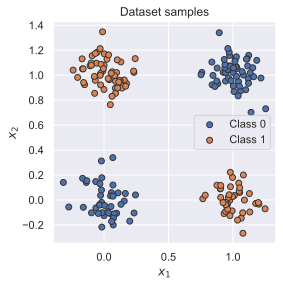

In [32]:
visualize_samples(dataset.data, dataset.label)
plt.show()

#### The data loader class

The class **`torch.utils.data.DataLoader`** is a Python iterable over a dataset with support for automatic batching, multi-process data loading, and many other features.
* It communicate with dataset class via `__getitem__` and stacks the outputs as tensors over the first dimension to form a batch.
* There is usually no need to define the data loader, which is different from the dataset class.
* We can configure the data loader via the following arguments:
  * **`batch_size`**: **Number of samples** to stack **per batch**
  * **`shuffle`**: If **`True`**, the data is returned in a **random order**. It's important for stochasticity in training.
  * **`num_workers`**: Number of subprocesses to use for data loading.
    * The default is `0`, which means that the data will be loaded in the main process, which can slow down the training for datasets since loading data also requires time.
    * More workers are recommended for larger datasets. For tiny datasets, 0 workers would be sufficient.
  * **`pin_memory`**: If **`True`**, the data loader will copy Tensors into CUDA pinned memory before returning them.
    * It can save time for large data points on GPU.
    * It is a good practice for **training data** but not necessary for **validation and testing data**
  * **`drop_last`**: If **`True`**, the last batch will be dropped if it is not complete.
    * It is useful when the dataset size is **not divisible** by the batch size.

In [33]:
data_loader = data.DataLoader(dataset, batch_size=8, shuffle=True)

In [34]:
# If `shuffle=True`, the `next` would return a different batch each time
data_inputs, data_labels = next(iter(data_loader))

print("Data inputs", data_inputs.shape, "\n", data_inputs)
print("Data labels", data_labels.shape, "\n", data_labels)

Data inputs torch.Size([8, 2]) 
 tensor([[-0.0274,  1.0140],
        [-0.0265,  0.9222],
        [ 0.2296,  1.0331],
        [ 1.1541,  1.0600],
        [ 1.1407,  0.7022],
        [ 0.0355,  1.1625],
        [ 0.9590, -0.0739],
        [ 0.0557,  1.0158]])
Data labels torch.Size([8]) 
 tensor([1, 1, 1, 0, 0, 1, 1, 1])


### The optimization

During training, we usually perform the following steps:
* Get a batch from the data loader.
* Obtain the predictions from the model for the batch.
* Calculate the loss based on the difference between predictions and labels.
* Backpropagation: calculate the gradients for every parameter with respect to the loss.
* Update the parameters of the model in the direction of the gradients.

#### The loss function

* For binary classification, we use **Binary Cross Entropy(BCE)** to calculate the loss.

<math xmlns="http://www.w3.org/1998/Math/MathML" display="block">
  <msub>
    <mrow data-mjx-texclass="ORD">
      <mi data-mjx-variant="-tex-calligraphic" mathvariant="script">L</mi>
    </mrow>
    <mrow data-mjx-texclass="ORD">
      <mi>B</mi>
      <mi>C</mi>
      <mi>E</mi>
    </mrow>
  </msub>
  <mo>=</mo>
  <mo>&#x2212;</mo>
  <munder>
    <mo data-mjx-texclass="OP">&#x2211;</mo>
    <mi>i</mi>
  </munder>
  <mrow data-mjx-texclass="INNER">
    <mo data-mjx-texclass="OPEN">[</mo>
    <msub>
      <mi>y</mi>
      <mi>i</mi>
    </msub>
    <mi>log</mi>
    <mo data-mjx-texclass="NONE">&#x2061;</mo>
    <msub>
      <mi>x</mi>
      <mi>i</mi>
    </msub>
    <mo>+</mo>
    <mo stretchy="false">(</mo>
    <mn>1</mn>
    <mo>&#x2212;</mo>
    <msub>
      <mi>y</mi>
      <mi>i</mi>
    </msub>
    <mo stretchy="false">)</mo>
    <mi>log</mi>
    <mo data-mjx-texclass="NONE">&#x2061;</mo>
    <mo stretchy="false">(</mo>
    <mn>1</mn>
    <mo>&#x2212;</mo>
    <msub>
      <mi>x</mi>
      <mi>i</mi>
    </msub>
    <mo stretchy="false">)</mo>
    <mo data-mjx-texclass="CLOSE">]</mo>
  </mrow>
</math>

* PyTorch has already provided a list of loss functions to use, for BCE, there are `nn.BCELoss()` and `nn.BCEWithLogitsLoss()`.
  * The `nn.BCELoss()` requires the inputs to be in the range [0, 1], i.e. the output of a sigmoid. `nn.BCEWithLogitsLoss()` combines a sigmoid layer and the BCE loss in a single class. Thus, it is **numerically more stable**.
  * Hence, it is advised to **use loss functions applied on "logits" where possible**.

In [35]:
loss_module = nn.BCEWithLogitsLoss()

#### Stochastic Gradient Descent (SGD)


* PyTorch provides the package `torch.optim` that implements various optimization algorithms.
* SGD updates parameters by multiplying the gradient by a learning rate, and subtracting those from the parameters(hence minimizing the loss).


In [36]:
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

* The `optimizer` provides:
  * **`optimizer.step()`**: updates the parameters based on the gradients.
  * **`optimizer.zero_grad()`**: sets the gradients of all parameters to zero, which is a crucial pre-step before performing backpropagation.

* Remember to call `optimizer.zero_grad()` before calculating the gradients of a batch. Otherwise, if we call the `backward` function without zeroing the gradients, it will be added to the previous ones instead of overwriting them. This is because a parameter might occur multiple times in a computation graph, and we need to sum the gradients in this case instead of replacing them.


#### Training

In [37]:
train_dataset = XORDataset(size=2500)
train_data_loader = data.DataLoader(train_dataset, batch_size=128, shuffle=True)

* For this (tiny) task, pushing the model and data into the GPU device actually takes more time than training on the CPU. But for a larger network, the speedup can be significant.

In [38]:
model.to(device)

SimpleClassifier(
  (linear1): Linear(in_features=2, out_features=4, bias=True)
  (act_fn): Tanh()
  (linear2): Linear(in_features=4, out_features=1, bias=True)
)

* Make sure to set the model to **training mode** by calling **`model.train()`**.
* For evaluation, set the model to **evaluation mode** by calling **`model.eval()`**.

In [39]:
def train_model(model, optimizer, data_loader, loss_module, num_epochs=100):
    # Set model to train mode
    model.train()

    # Training loop
    for epoch in tqdm(range(num_epochs)):
        for data_inputs, data_labels in data_loader:

            ## Step 1: Move input data to device
            data_inputs = data_inputs.to(device)
            data_labels = data_labels.to(device)

            ## Step 2: Run the model on the input data
            preds = model(data_inputs)
            preds = preds.squeeze(dim=1) # Output is [Batch size, 1], but we want [Batch size]

            ## Step 3: Calculate the loss
            loss = loss_module(preds, data_labels.float())

            ## Step 4: Perform backpropagation
            # Before calculating the gradients, we need to ensure that they are all zero.
            # The gradients would not be overwritten, but actually added to the existing ones.
            optimizer.zero_grad()
            # Perform backpropagation
            loss.backward()

            ## Step 5: Update the parameters
            optimizer.step()

In [40]:
train_model(model, optimizer, train_data_loader, loss_module)

  0%|          | 0/100 [00:00<?, ?it/s]

#### Saving a model

* We can save the trained model to disk to load the weights later by using extracting the **`state_dict()`** of the model and using **`torch.save()`** to save it.`

In [41]:
state_dict = model.state_dict()
print(state_dict)

OrderedDict({'linear1.weight': tensor([[-1.8100,  2.6423],
        [-3.0006, -3.1494],
        [-2.4393,  1.5068],
        [ 1.5659,  1.3679]], device='mps:0'), 'linear1.bias': tensor([ 0.7786,  1.2432, -0.5491, -2.2034], device='mps:0'), 'linear2.weight': tensor([[-3.3445, -4.2872,  3.0261, -2.9921]], device='mps:0'), 'linear2.bias': tensor([-0.7269], device='mps:0')})


In [42]:
torch.save(state_dict, 'model.tar')

In order to load a saved model, we need to create a model instance first and use **`load_state_dict(torch.load())`** to load the weights.

In [43]:
state_dict = torch.load('model.tar')

new_model = SimpleClassifier(num_inputs=2, num_hidden=4, num_outputs=1)
new_model.load_state_dict(state_dict)

print("Original model\n", model.state_dict())
print("\nLoaded model\n", new_model.state_dict())


Original model
 OrderedDict({'linear1.weight': tensor([[-1.8100,  2.6423],
        [-3.0006, -3.1494],
        [-2.4393,  1.5068],
        [ 1.5659,  1.3679]], device='mps:0'), 'linear1.bias': tensor([ 0.7786,  1.2432, -0.5491, -2.2034], device='mps:0'), 'linear2.weight': tensor([[-3.3445, -4.2872,  3.0261, -2.9921]], device='mps:0'), 'linear2.bias': tensor([-0.7269], device='mps:0')})

Loaded model
 OrderedDict({'linear1.weight': tensor([[-1.8100,  2.6423],
        [-3.0006, -3.1494],
        [-2.4393,  1.5068],
        [ 1.5659,  1.3679]]), 'linear1.bias': tensor([ 0.7786,  1.2432, -0.5491, -2.2034]), 'linear2.weight': tensor([[-3.3445, -4.2872,  3.0261, -2.9921]]), 'linear2.bias': tensor([-0.7269])})


### Evaluation

First, create a test dataset.

In [44]:
test_dataset = XORDataset(size=500)
test_data_loader = data.DataLoader(test_dataset, batch_size=128, shuffle=True)

As metric, we will use accuracy.
<math xmlns="http://www.w3.org/1998/Math/MathML" display="block">
  <mi>a</mi>
  <mi>c</mi>
  <mi>c</mi>
  <mo>=</mo>
  <mfrac>
    <mrow>
      <mi mathvariant="normal">#</mi>
      <mtext>correct predictions</mtext>
    </mrow>
    <mrow>
      <mi mathvariant="normal">#</mi>
      <mtext>all predictions</mtext>
    </mrow>
  </mfrac>
  <mo>=</mo>
  <mfrac>
    <mrow>
      <mi>T</mi>
      <mi>P</mi>
      <mo>+</mo>
      <mi>T</mi>
      <mi>N</mi>
    </mrow>
    <mrow>
      <mi>T</mi>
      <mi>P</mi>
      <mo>+</mo>
      <mi>T</mi>
      <mi>N</mi>
      <mo>+</mo>
      <mi>F</mi>
      <mi>P</mi>
      <mo>+</mo>
      <mi>F</mi>
      <mi>N</mi>
    </mrow>
  </mfrac>
</math>

* Don't forget to set the model to eval mode by **`model.eval()`**.
* For **testing**, there is **no need to calculate gradients** and keep track of the computation graph, so using **`with torch.no_grad():`** to deactivate the gradient calculation.

In [45]:
def eval_model(model, data_loader):
  # set model to eval mode
  model.eval()
  true_preds, num_preds = 0., 0

  with torch.no_grad():
    for data_inputs, data_labels in data_loader:
      data_inputs, data_labels = data_inputs.to(device), data_labels.to(device)
      preds = model(data_inputs)
      preds = preds.squeeze(dim=1)
      preds = torch.sigmoid(preds)
      pred_labels = (preds >= 0.5).long()

      true_preds += (pred_labels == data_labels).sum()
      num_preds += data_labels.shape[0]

    acc = true_preds / num_preds
    print(f"Accuracy of the model: {100.0*acc:4.2f}%")

In [46]:
eval_model(model, test_data_loader)

Accuracy of the model: 100.00%


#### Visualizing classification boundaries

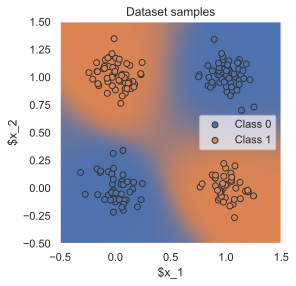

In [47]:
@torch.no_grad()
def visualize_classification(model, data, label):
  if isinstance(data, torch.Tensor):
    data = data.cpu().numpy()
  if isinstance(label, torch.Tensor):
    label = label.cpu().numpy()
  
  data_0 = data[label == 0]
  data_1 = data[label == 1]

  fig = plt.figure(figsize=(4,4), dpi=500)
  plt.scatter(data_0[:,0], data_0[:,1], edgecolor="#333", label="Class 0")
  plt.scatter(data_1[:,0], data_1[:,1], edgecolor="#333", label="Class 1")
  plt.title("Dataset samples")
  plt.ylabel(r"$x_2")
  plt.xlabel(r"$x_1")
  plt.legend()

  model.to(device)
  c0 = torch.Tensor(to_rgba("C0")).to(device)
  c1 = torch.Tensor(to_rgba("C1")).to(device)
  x1 = torch.arange(-0.5, 1.5, step=0.01, device=device)
  x2 = torch.arange(-0.5, 1.5, step=0.01, device=device)
  xx1, xx2 = torch.meshgrid(x1, x2, indexing="ij")
  model_inputs = torch.stack([xx1, xx2], dim=-1)
  preds = model(model_inputs)
  preds = torch.sigmoid(preds)
  output_image = (1 - preds) * c0[None, None] + preds * c1[None, None]
  output_image = output_image.cpu().numpy()
  plt.imshow(output_image, origin="lower", extent=(-0.5, 1.5, -0.5, 1.5))
  plt.grid(False)
  return fig

_ = visualize_classification(model, dataset.data, dataset.label)
plt.show()

### Monitoring

#### TensorBoard logging

TensorBoard is a logging and visualization tool for training deep learning models.

In [4]:
# Import tensorboard logger from PyTorch
from torch.utils.tensorboard import SummaryWriter

# Load tensorboard extension for Jupyter 
# This line is required if you want to run TensorBoard directly in Jupyter Notebook
%load_ext tensorboard

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


* Start the logging process by creating a new object `writer = SummaryWriter()`, where we specify the directory in which the logging file should be saved.
* With this object, we call different functions like `writer.add_` to log different aspects of the model.

In [5]:
def train_model_with_logger(model, optimizer, data_loader, loss_module, val_dataset, num_epochs=100, logging_dir='runs/our_experiment'):
    # create TensorBoard logger object
    writer = SummaryWriter(logging_dir)
    model_plotted = False

    # set model to training mode
    model.train()

    # training loop
    for epoch in tqdm(range(num_epochs)):
        epoch_loss = 0.0
        for data_inputs, data_labels in data_loader:
            # step1: move input data to device
            data_inputs = data_inputs.to(device)
            data_labels = data_labels.to(device)

            # for the first batch, visualize the computation graph
            if not model_plotted:
                writer.add_graph(model, data_inputs)
                model_plotted = True
            
            # step2: forward pass
            preds = model(data_inputs)
            preds = preds.squeeze(dim=1)

            # step3: calculate loss
            loss = loss_module(preds, data_labels.float())

            # step4: perform backpropagation
            optimizer.zero_grad()
            loss.backward()

            # step5: update model parameters
            optimizer.step()

            # step6: average the loss
            epoch_loss += loss.item()

        # add average loss to TensorBoard
        epoch_loss /= len(data_loader)
        writer.add_scalar('training_loss', epoch_loss, global_step = epoch + 1)

        # visualize predictions and add figure to TensorBoard
        if (epoch + 1) % 10 == 0:
            fig = visualize_classification(model, val_dataset.data, val_dataset.label)
            writer.add_figure('predictions', fig, global_step = epoch + 1)
        
    writer.close()

In [52]:
model = SimpleClassifier(num_inputs=2, num_hidden=4, num_outputs=1).to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)
train_model_with_logger(model, optimizer, train_data_loader, loss_module, val_dataset=dataset)

  0%|          | 0/100 [00:00<?, ?it/s]

In [54]:
%tensorboard --logdir runs/our_experiment

Reusing TensorBoard on port 6006 (pid 305), started 0:00:14 ago. (Use '!kill 305' to kill it.)